In [46]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from ipywidgets import IntSlider, interact
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolDescriptors
from tqdm import tqdm

ROOT = "/home/rjacob/NEAT-Cond-Dev"

# Load and explore CrossDocked data

In [47]:
split_file_path = os.path.join(ROOT, "data", "CROSSDOCKED", "raw", "split_by_name.pt")
data_split = torch.load(split_file_path, map_location="cpu", weights_only=False)

In [48]:
len(data_split["train"]), len(data_split["test"])

(100000, 100)

In [49]:
selected_ligand_files_train = [ligand_file for pocket_file, ligand_file in data_split["train"]]
selected_ligand_files_test = [ligand_file for pocket_file, ligand_file in data_split["test"]]
selected_ligand_files = selected_ligand_files_train + selected_ligand_files_test

selected_ligand_files_tupled = [(file.split("/")[0], file.split("/")[1]) for file in selected_ligand_files]

len(selected_ligand_files_tupled)

100100

In [50]:
DATA_DIR = os.path.join(ROOT, "data", "CROSSDOCKED", "raw", "crossdocked_pocket10")

ligands = []

for pocket_dir in tqdm(os.listdir(DATA_DIR)):
    pocket_path = os.path.join(DATA_DIR, pocket_dir)
    if os.path.isdir(pocket_path):
        for file in os.listdir(pocket_path):
            if file.endswith(".sdf"):
                if (pocket_dir, file) in selected_ligand_files_tupled:
                    ligand_file_path = os.path.join(pocket_path, file)
                    suppl = Chem.SDMolSupplier(str(ligand_file_path), sanitize=True, removeHs=False)
                    ligand = suppl[0]
                    if ligand is not None:
                        ligands.append(ligand)

  1%|          | 14/2464 [00:01<03:15, 12.52it/s]


KeyboardInterrupt: 

In [ ]:
print("Number of ligands:", len(ligands))

Number of ligands: 100100


In [ ]:
canonical_smiles = [Chem.MolToSmiles(ligand, isomericSmiles=True, canonical=True) for ligand in ligands]
print("Number of unique ligands:", len(set(canonical_smiles)))

Number of unique ligands: 9075


By using the sanitization flag, we loose 183468-166890=16578 original ligands (13772-12161=1611 unique original ligands).

By applying the pre-selection from Luo, we obtain 100124 ligands (9075 unique ligands). All pre-selected ligands cause no problem with RDKit sanitization.

In [ ]:
ligands_unique = [ligands[i] for i in range(len(ligands)) if canonical_smiles[i] not in canonical_smiles[:i]]

In [ ]:
# @interact(i=IntSlider(min=0, max=len(ligands_unique) - 1, step=1))
# def visualize_ligand(i):
#     ligand = ligands_unique[i]
#     ligand.Compute2DCoords()
#     img = Chem.Draw.MolToImage(ligand, size=(400, 400))
#     display(img)

In [ ]:
def get_num_fragments(ligand):
    return len(Chem.GetMolFrags(ligand, asMols=True, sanitizeFrags=True))

num_fragments = [get_num_fragments(ligand) for ligand in ligands_unique]

print("Number of fragments:", np.unique(num_fragments, return_counts=True))

Number of fragments: (array([1]), array([9075]))


There is no multiple fragment compound.

In [ ]:
def get_num_atoms(ligand):
    return rdMolDescriptors.CalcNumAtoms(ligand)

def get_num_heavy_atoms(ligand):
    return rdMolDescriptors.CalcNumHeavyAtoms(ligand)

def get_mol_weight(ligand):
    return rdMolDescriptors.CalcExactMolWt(ligand)

def get_num_hba(ligand):
    return rdMolDescriptors.CalcNumHBA(ligand)

def get_num_hbd(ligand):
    return rdMolDescriptors.CalcNumHBD(ligand)

def get_num_stereocenters(ligand):
    return rdMolDescriptors.CalcNumAtomStereoCenters(ligand)

def get_num_stereocenters(ligand):
    return rdMolDescriptors.CalcNumAtomStereoCenters(ligand)

def get_num_halogens(ligand):
    sum_x = 0
    for atom in ligand.GetAtoms():
        if atom.GetAtomicNum() in [9, 17, 35, 53]:
            sum_x += 1
    return sum_x

def get_num_rings(ligand):
    return rdMolDescriptors.CalcNumRings(ligand)

def get_num_aromatic_rings(ligand):
    return rdMolDescriptors.CalcNumAromaticRings(ligand)

def get_frac_rotatable_bonds(ligand):
    return rdMolDescriptors.CalcNumRotatableBonds(ligand) / ligand.GetNumBonds()

num_atoms = [get_num_atoms(ligand) for ligand in ligands_unique]
num_heavy_atoms = [get_num_heavy_atoms(ligand) for ligand in ligands_unique]
mol_weights = [get_mol_weight(ligand) for ligand in ligands_unique]
num_hba = [get_num_hba(ligand) for ligand in ligands_unique]
num_hbd = [get_num_hbd(ligand) for ligand in ligands_unique]
num_stereocenters = [get_num_stereocenters(ligand) for ligand in ligands_unique]
num_halogens = [get_num_halogens(ligand) for ligand in ligands_unique]
num_rings = [get_num_rings(ligand) for ligand in ligands_unique]
num_aromatic_rings = [get_num_aromatic_rings(ligand) for ligand in ligands_unique]
frac_rotatable_bonds = [get_frac_rotatable_bonds(ligand) for ligand in ligands_unique]

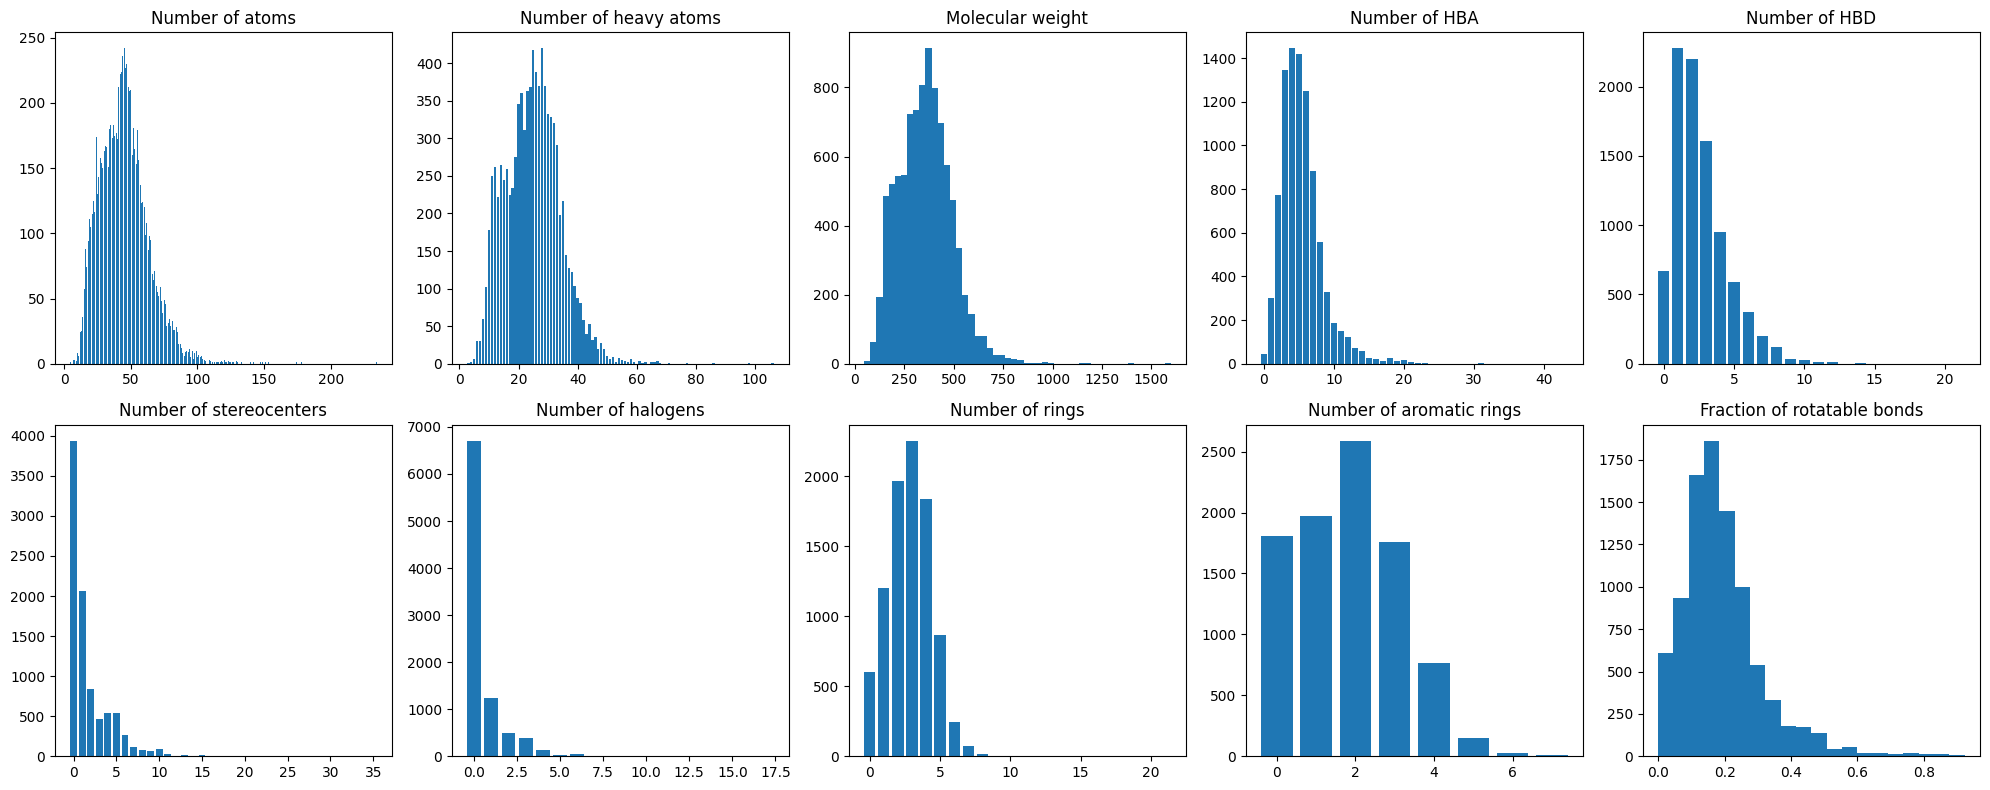

In [ ]:
ax, fig = plt.subplots(2, 5, figsize=(20, 8))

fig[0, 0].bar(np.unique(num_atoms, return_counts=True)[0], np.unique(num_atoms, return_counts=True)[1])
fig[0, 0].set_title("Number of atoms")
fig[0, 1].bar(np.unique(num_heavy_atoms, return_counts=True)[0], np.unique(num_heavy_atoms, return_counts=True)[1])
fig[0, 1].set_title("Number of heavy atoms")
fig[0, 2].hist(mol_weights, bins=50)
fig[0, 2].set_title("Molecular weight")
fig[0, 3].bar(np.unique(num_hba, return_counts=True)[0], np.unique(num_hba, return_counts=True)[1])
fig[0, 3].set_title("Number of HBA")
fig[0, 4].bar(np.unique(num_hbd, return_counts=True)[0], np.unique(num_hbd, return_counts=True)[1])
fig[0, 4].set_title("Number of HBD")
fig[1, 0].bar(np.unique(num_stereocenters, return_counts=True)[0], np.unique(num_stereocenters, return_counts=True)[1])
fig[1, 0].set_title("Number of stereocenters")
fig[1, 1].bar(np.unique(num_halogens, return_counts=True)[0], np.unique(num_halogens, return_counts=True)[1])
fig[1, 1].set_title("Number of halogens")
fig[1, 2].bar(np.unique(num_rings, return_counts=True)[0], np.unique(num_rings, return_counts=True)[1])
fig[1, 2].set_title("Number of rings")
fig[1, 3].bar(np.unique(num_aromatic_rings, return_counts=True)[0], np.unique(num_aromatic_rings, return_counts=True)[1])
fig[1, 3].set_title("Number of aromatic rings")
fig[1, 4].hist(frac_rotatable_bonds, bins=20)
fig[1, 4].set_title("Fraction of rotatable bonds")

plt.tight_layout()
plt.show()

In [ ]:
def count_all_atom_types(ligands):
    atom_counts = {}
    for ligand in ligands:
        for atom in ligand.GetAtoms():
            atom_type = atom.GetSymbol()
            if atom_type not in atom_counts:
                atom_counts[atom_type] = 1
            else:
                atom_counts[atom_type] += 1
    return dict(sorted(atom_counts.items(), key=lambda x: x[1], reverse=True))

atom_counts = count_all_atom_types(ligands_unique)

In [ ]:
atom_counts

{'C': 155885,
 'O': 35337,
 'N': 25251,
 'F': 3000,
 'S': 2863,
 'P': 1699,
 'Cl': 1648,
 'H': 943}

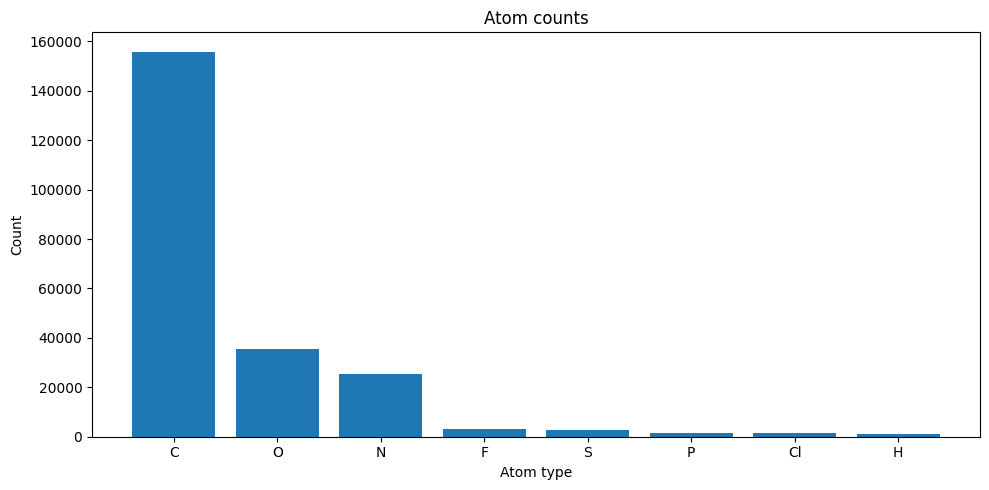

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.bar(atom_counts.keys(), atom_counts.values())
ax.set_title("Atom counts")
ax.set_xlabel("Atom type")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

Using the pre-selection by Luo also removes all ligands with weird atom types.

# Check whether all CrossDocked ligand pass NEAT's metrics

First we need to add all implicit hydrogen atoms.

In [ ]:
def add_hydrogens(mol: Chem.Mol, max_attempts: int = 50) -> Chem.Mol:
    try:
        mol_h = Chem.AddHs(mol)
        AllChem.ConstrainedEmbed(mol_h, mol, maxAttempts=max_attempts)
        return mol_h
    except Exception as e:
        return None

ligands_unique_hydrogens = [add_hydrogens(ligand) for ligand in ligands_unique]
ligands_unique_hydrogens = [ligand for ligand in ligands_unique_hydrogens if ligand is not None]

[15:48:45] UFFTYPER: Unrecognized atom type: S_5+4 (7)
[15:48:47] UFFTYPER: Unrecognized atom type: S_5+4 (9)
[15:48:50] UFFTYPER: Warning: hybridization set to SP3 for atom 17
[15:48:50] UFFTYPER: Warning: hybridization set to SP3 for atom 17
[15:48:56] Could not triangle bounds smooth molecule.
[15:48:56] Could not triangle bounds smooth molecule.
[15:48:56] Could not triangle bounds smooth molecule.
[15:49:03] UFFTYPER: Unrecognized atom type: S_5+4 (28)
[15:49:03] UFFTYPER: Unrecognized atom type: S_5+4 (42)
[15:49:03] UFFTYPER: Unrecognized atom type: S_5+4 (15)
[15:49:07] Could not triangle bounds smooth molecule.
[15:49:09] UFFTYPER: Unrecognized atom type: S_5+4 (19)
[15:49:09] UFFTYPER: Unrecognized atom type: S_5+4 (10)
[15:49:10] UFFTYPER: Unrecognized atom type: S_5+4 (19)
[15:49:18] Could not triangle bounds smooth molecule.
[15:49:23] UFFTYPER: Unrecognized atom type: S_5+4 (19)
[15:49:23] UFFTYPER: Unrecognized atom type: S_5+4 (6)
[15:49:25] Could not triangle bounds sm

In [ ]:
len(ligands_unique_hydrogens)

8731

Next we need to convert the RDKit Mol objects to a generated_mols batch object.

In [ ]:
from torch_geometric.data import Batch

mapping = {
    1: 1,
    5: 2,
    6: 3,
    7: 4,
    8: 5,
    9: 6,
    13: 7,
    14: 8,
    15: 9,
    16: 10,
    17: 11,
    33: 12,
    35: 13,
    53: 14,
    80: 15,
    83: 16,
}

x = []
pos = []
batch = []
for i, mol in enumerate(ligands_unique_hydrogens):
    conformer = mol.GetConformer()
    x.append(torch.tensor([mapping[atom.GetAtomicNum()] for atom in mol.GetAtoms()], dtype=torch.long))
    sub_pos = []
    for atom in mol.GetAtoms():
        coords = conformer.GetAtomPosition(atom.GetIdx())
        coords = torch.tensor([coords.x, coords.y, coords.z], dtype=torch.float)
        sub_pos.append(coords)
    pos.append(torch.stack(sub_pos, dim=0))
    batch.append(torch.full((mol.GetNumAtoms(),), i, dtype=torch.long))
x = torch.cat(x, dim=0)
pos = torch.cat(pos, dim=0)
batch = torch.cat(batch, dim=0)
generated_mols = Batch(x=x, pos=pos, batch=batch)
os.makedirs(os.path.join("output", "data", "crossdocked", "seed_0"), exist_ok=True)
torch.save(generated_mols, os.path.join("output", "data", "crossdocked", "seed_0", "generated_mols.pt"))

# Compare with GEOM data

In [ ]:
# Recalculate properties for crossdocked ligands with hydrogens added

num_atoms_crossdocked = [get_num_atoms(ligand) for ligand in ligands_unique_hydrogens]
num_heavy_atoms_crossdocked = [get_num_heavy_atoms(ligand) for ligand in ligands_unique_hydrogens]
mol_weights_crossdocked = [get_mol_weight(ligand) for ligand in ligands_unique_hydrogens]
num_hba_crossdocked = [get_num_hba(ligand) for ligand in ligands_unique_hydrogens]
num_hbd_crossdocked = [get_num_hbd(ligand) for ligand in ligands_unique_hydrogens]
num_stereocenters_crossdocked = [get_num_stereocenters(ligand) for ligand in ligands_unique_hydrogens]
num_halogens_crossdocked = [get_num_halogens(ligand) for ligand in ligands_unique_hydrogens]
num_rings_crossdocked = [get_num_rings(ligand) for ligand in ligands_unique_hydrogens]
num_aromatic_rings_crossdocked = [get_num_aromatic_rings(ligand) for ligand in ligands_unique_hydrogens]
frac_rotatable_bonds_crossdocked = [get_frac_rotatable_bonds(ligand) for ligand in ligands_unique_hydrogens]

In [ ]:
# Load only 5,000 random graphs from the GEOM dataset for faster processing

import random

from neat.dataset.datamodule import DataModule
from neat.model.molecule_builder import MoleculeBuilder

DATA_ROOT = os.path.join(ROOT, "data")
datamodule = DataModule(DATA_ROOT, data_set="GEOM")
datamodule.setup()
val_data = datamodule.validation_data

x = val_data.x
pos = val_data.pos
num_nodes_per_graph = torch.tensor([data.num_nodes for data in val_data], dtype=torch.long)
batch = torch.repeat_interleave(torch.arange(1, len(num_nodes_per_graph) + 1), num_nodes_per_graph)

print(x.shape, pos.shape, batch.shape)

unique_graph_indices = torch.unique(batch)
random_graph_indices = random.sample(unique_graph_indices.tolist(), 10000)
random_indices = torch.cat([torch.where(batch == idx)[0] for idx in random_graph_indices], dim=0)

x_sub = x[random_indices]
pos_sub = pos[random_indices]
batch_sub = batch[random_indices]

print(x_sub.shape, pos_sub.shape, batch_sub.shape)

builder = MoleculeBuilder(vocab="GEOM")
ligands_geom = builder.generate_rdkit_molecules_via_xyz2mol(x_sub, pos_sub, batch_sub)
ligands_geom = [ligand for ligand in ligands_geom if ligand is not None]

Using GEOM dataset.
Number of training graphs: 1172436
Number of validation graphs: 146394
Number of test graphs: 146788
torch.Size([6555837]) torch.Size([6555837, 3]) torch.Size([6555837])


torch.Size([446835]) torch.Size([446835, 3]) torch.Size([446835])


In [ ]:
print("Number of ligands in GEOM subset:", len(ligands_geom))

Number of ligands in GEOM subset: 9408


In [ ]:
canonical_smiles_geom = [Chem.MolToSmiles(ligand, isomericSmiles=True, canonical=True) for ligand in ligands_geom]
ligands_unique_geom = [ligands_geom[i] for i in range(len(ligands_geom)) if canonical_smiles_geom[i] not in canonical_smiles_geom[:i]]

In [ ]:
print("Number of unique ligands in GEOM subset:", len(ligands_unique_geom))

Number of unique ligands in GEOM subset: 8255


In [ ]:
num_atoms_geom = [get_num_atoms(ligand) for ligand in ligands_unique_geom]
num_heavy_atoms_geom  = [get_num_heavy_atoms(ligand) for ligand in ligands_unique_geom]
mol_weights_geom  = [get_mol_weight(ligand) for ligand in ligands_unique_geom]
num_hba_geom  = [get_num_hba(ligand) for ligand in ligands_unique_geom]
num_hbd_geom  = [get_num_hbd(ligand) for ligand in ligands_unique_geom]
num_stereocenters_geom  = [get_num_stereocenters(ligand) for ligand in ligands_unique_geom]
num_halogens_geom  = [get_num_halogens(ligand) for ligand in ligands_unique_geom]
num_rings_geom  = [get_num_rings(ligand) for ligand in ligands_unique_geom]
num_aromatic_rings_geom  = [get_num_aromatic_rings(ligand) for ligand in ligands_unique_geom]
frac_rotatable_bonds_geom  = [get_frac_rotatable_bonds(ligand) for ligand in ligands_unique_geom]

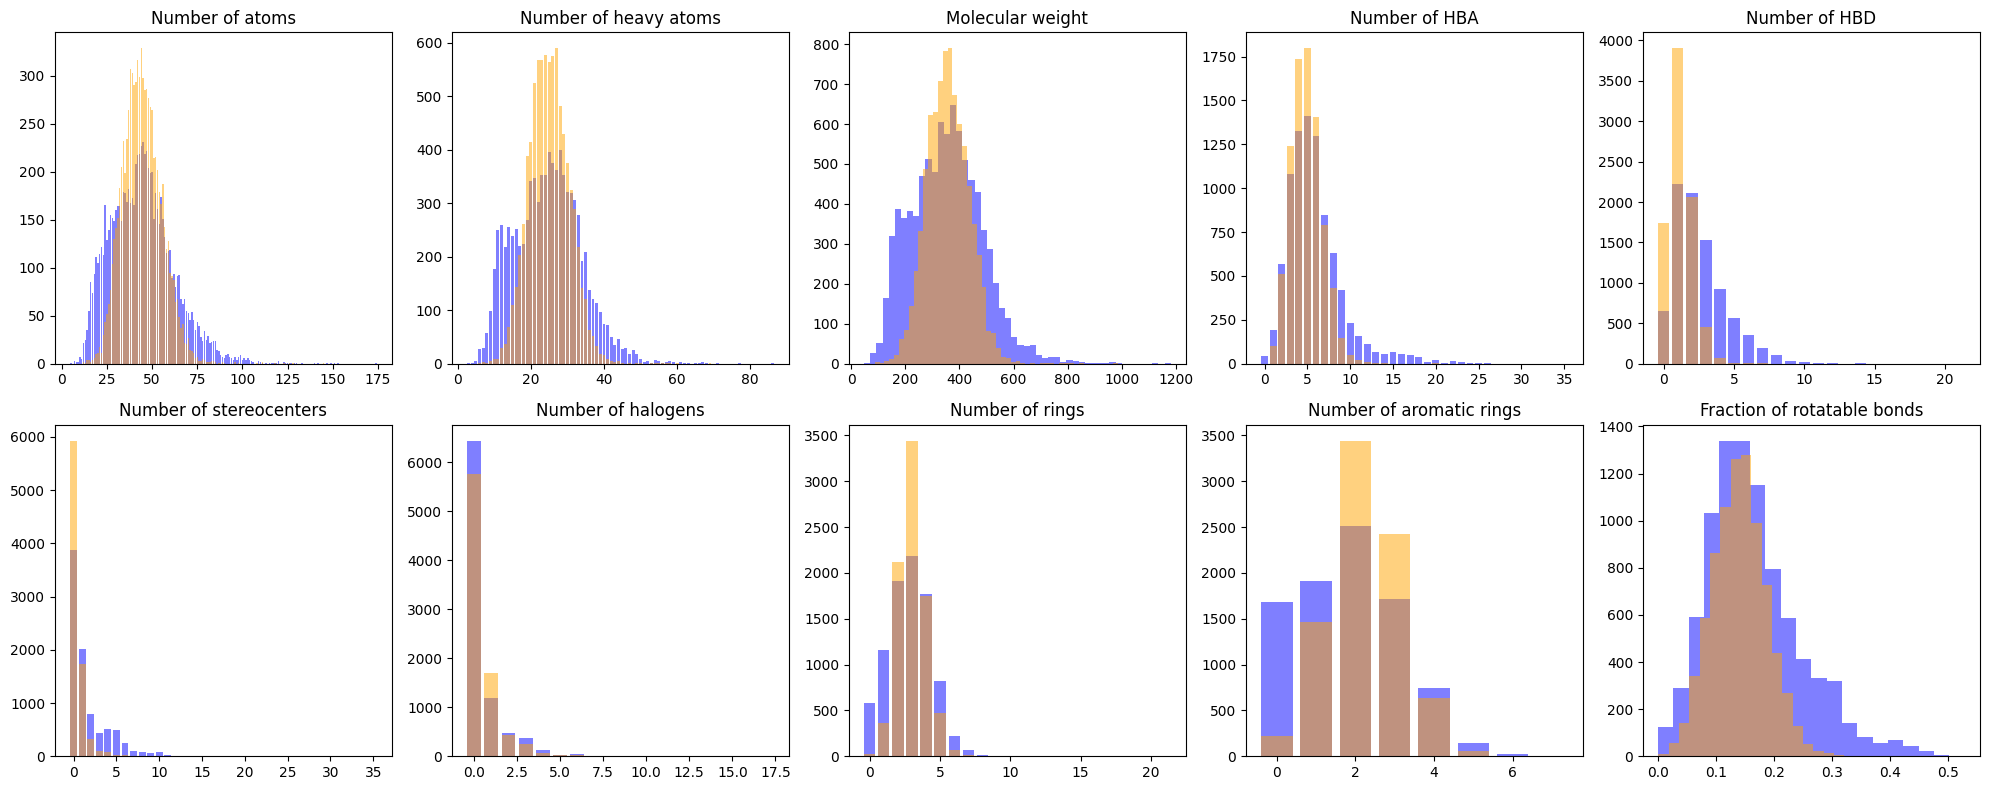

In [ ]:
ax, fig = plt.subplots(2, 5, figsize=(20, 8))

fig[0, 0].bar(np.unique(num_atoms_crossdocked, return_counts=True)[0], np.unique(num_atoms_crossdocked, return_counts=True)[1], color="blue", alpha=0.5, label="CrossDocked")
fig[0, 0].bar(np.unique(num_atoms_geom, return_counts=True)[0], np.unique(num_atoms_geom, return_counts=True)[1], color="orange", alpha=0.5, label="GEOM")
fig[0, 0].set_title("Number of atoms")
fig[0, 1].bar(np.unique(num_heavy_atoms_crossdocked, return_counts=True)[0], np.unique(num_heavy_atoms_crossdocked, return_counts=True)[1], color="blue", alpha=0.5, label="CrossDocked")
fig[0, 1].bar(np.unique(num_heavy_atoms_geom, return_counts=True)[0], np.unique(num_heavy_atoms_geom, return_counts=True)[1], color="orange", alpha=0.5, label="GEOM")
fig[0, 1].set_title("Number of heavy atoms")
fig[0, 2].hist(mol_weights_crossdocked, bins=50, color="blue", alpha=0.5, label="CrossDocked")
fig[0, 2].hist(mol_weights_geom, bins=50, color="orange", alpha=0.5, label="GEOM")
fig[0, 2].set_title("Molecular weight")
fig[0, 3].bar(np.unique(num_hba_crossdocked, return_counts=True)[0], np.unique(num_hba_crossdocked, return_counts=True)[1], color="blue", alpha=0.5, label="CrossDocked")
fig[0, 3].bar(np.unique(num_hba_geom, return_counts=True)[0], np.unique(num_hba_geom, return_counts=True)[1], color="orange", alpha=0.5, label="GEOM")
fig[0, 3].set_title("Number of HBA")
fig[0, 4].bar(np.unique(num_hbd_crossdocked, return_counts=True)[0], np.unique(num_hbd_crossdocked, return_counts=True)[1], color="blue", alpha=0.5, label="CrossDocked")
fig[0, 4].bar(np.unique(num_hbd_geom, return_counts=True)[0], np.unique(num_hbd_geom, return_counts=True)[1], color="orange", alpha=0.5, label="GEOM")
fig[0, 4].set_title("Number of HBD")
fig[1, 0].bar(np.unique(num_stereocenters_crossdocked, return_counts=True)[0], np.unique(num_stereocenters_crossdocked, return_counts=True)[1], color="blue", alpha=0.5, label="CrossDocked")
fig[1, 0].bar(np.unique(num_stereocenters_geom, return_counts=True)[0], np.unique(num_stereocenters_geom, return_counts=True)[1], color="orange", alpha=0.5, label="GEOM")
fig[1, 0].set_title("Number of stereocenters")
fig[1, 1].bar(np.unique(num_halogens_crossdocked, return_counts=True)[0], np.unique(num_halogens_crossdocked, return_counts=True)[1], color="blue", alpha=0.5, label="CrossDocked")
fig[1, 1].bar(np.unique(num_halogens_geom, return_counts=True)[0], np.unique(num_halogens_geom, return_counts=True)[1], color="orange", alpha=0.5, label="GEOM")
fig[1, 1].set_title("Number of halogens")
fig[1, 2].bar(np.unique(num_rings_crossdocked, return_counts=True)[0], np.unique(num_rings_crossdocked, return_counts=True)[1], color="blue", alpha=0.5, label="CrossDocked")
fig[1, 2].bar(np.unique(num_rings_geom, return_counts=True)[0], np.unique(num_rings_geom, return_counts=True)[1], color="orange", alpha=0.5, label="GEOM")
fig[1, 2].set_title("Number of rings")
fig[1, 3].bar(np.unique(num_aromatic_rings_crossdocked, return_counts=True)[0], np.unique(num_aromatic_rings_crossdocked, return_counts=True)[1], color="blue", alpha=0.5, label="CrossDocked")
fig[1, 3].bar(np.unique(num_aromatic_rings_geom, return_counts=True)[0], np.unique(num_aromatic_rings_geom, return_counts=True)[1], color="orange", alpha=0.5, label="GEOM")
fig[1, 3].set_title("Number of aromatic rings")
fig[1, 4].hist(frac_rotatable_bonds_crossdocked, bins=20, color="blue", alpha=0.5, label="CrossDocked")
fig[1, 4].hist(frac_rotatable_bonds_geom, bins=20, color="orange", alpha=0.5, label="GEOM")
fig[1, 4].set_title("Fraction of rotatable bonds")

plt.tight_layout()
plt.show()

# Investigate failures

In [ ]:
log_file_path = os.path.join(ROOT, "data", "CROSSDOCKED", "processed", "log.txt")
problem_files = []
with open(log_file_path, "r") as f:
    for line in f:
        if "hydrogen" in line:
            ligand_part = line.split("/")[-1]
            ligand_part = ligand_part.split(".")[0]
            pocket_part = line.split("/")[-2]
            problem_files.append((pocket_part, ligand_part))

structure_files_dir = os.path.join(ROOT, "data", "CROSSDOCKED", "raw", "crossdocked_pocket10")
problem_ligands = []
for pocket_part, ligand_part in problem_files:
    pocket_path = os.path.join(structure_files_dir, pocket_part)
    for file in os.listdir(pocket_path):
        if file.endswith(".sdf"):
            if ligand_part in file:
                ligand = Chem.SDMolSupplier(os.path.join(pocket_path, file), sanitize=True, removeHs=False)[0]
                if ligand is not None:
                    problem_ligands.append(ligand)

print(f"Number of problem ligands: {len(problem_ligands)}")

Number of problem ligands: 2959


In [52]:
@interact(i=IntSlider(min=0, max=len(problem_ligands) - 1, step=1))
def visualize_ligand(i):
    ligand = problem_ligands[i]
    print(ligand.GetNumAtoms())
    # ligand.Compute2DCoords()
    img = Chem.Draw.MolToImage(ligand, size=(400, 400))
    display(img)

    ligand_h = Chem.AddHs(ligand)
    AllChem.ConstrainedEmbed(ligand_h, ligand, maxAttempts=50)
    img_h = Chem.Draw.MolToImage(ligand_h, size=(400, 400))
    display(img_h)

interactive(children=(IntSlider(value=0, description='i', max=2958), Output()), _dom_classes=('widget-interact…